In [1]:
#import keras
import tensorflow as tf
from tensorflow import keras
from IPython.display import Image
import matplotlib.pyplot as plt
#from keras import layers
#from keras import ops
from tensorflow.keras import layers
import os


In [2]:

train_ds = tf.keras.utils.image_dataset_from_directory(
    "rps-cv-images",
    validation_split=0.30,
    subset="training",
    seed=42,
    color_mode="grayscale",
    image_size=(200,200),
    batch_size=32
)

temp_ds = tf.keras.utils.image_dataset_from_directory(
    "rps-cv-images",
    validation_split=0.30,
    subset="validation",
    seed=42,
    color_mode="grayscale",
    image_size=(200,200),
    batch_size=32
)

temp_size = len(temp_ds)

val_size = temp_size // 2

val_ds = temp_ds.take(val_size)
test_ds = temp_ds.skip(val_size)


Found 2188 files belonging to 3 classes.
Using 1532 files for training.
Found 2188 files belonging to 3 classes.
Using 656 files for validation.


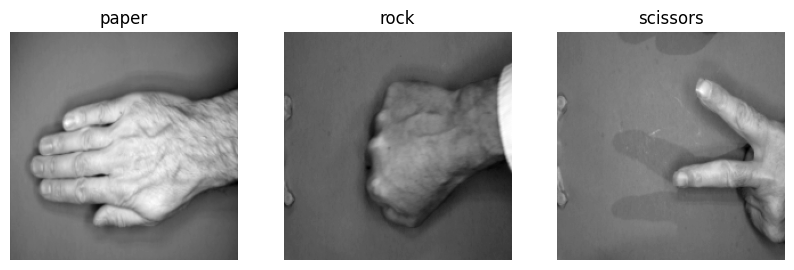

In [3]:
class_names = train_ds.class_names
# Display one image per class
shown_classes = set()
plt.figure(figsize=(10, 4))
for images, labels in train_ds.unbatch():
    label = labels.numpy()
    if label not in shown_classes:
        plt.subplot(1, len(class_names), len(shown_classes) + 1)
        plt.imshow(images.numpy().squeeze(), cmap="gray")  
        plt.title(class_names[label])
        plt.axis("off")
        shown_classes.add(label)
    if len(shown_classes) == len(class_names):
        break
plt.show()

In [4]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.2),
   
])

In [5]:
model_1 = keras.Sequential(
    [
    #data_augmentation,
    layers.Rescaling(1./255),
    layers.Resizing(96, 96),        
   layers.Conv2D(24, (3, 3), activation="relu", input_shape=(96, 96, 1)),
   layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(3,activation='softmax')

    ]
)

c:\Users\loren\anaconda3\envs\MLstat\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
model_1.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing (Resizing)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [7]:
model_1.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [8]:
model_1.fit(train_ds, validation_data=val_ds, epochs=10)

Epoch 1/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.3330 - loss: 1.4986 - val_accuracy: 0.3031 - val_loss: 1.1053
Epoch 2/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.3939 - loss: 1.0822 - val_accuracy: 0.4313 - val_loss: 1.0571
Epoch 3/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.4560 - loss: 1.0322 - val_accuracy: 0.5531 - val_loss: 0.9967
Epoch 4/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.5648 - loss: 0.9638 - val_accuracy: 0.4875 - val_loss: 0.9620
Epoch 5/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.5617 - loss: 0.9147 - val_accuracy: 0.5375 - val_loss: 0.9279
Epoch 6/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.6027 - loss: 0.8548 - val_accuracy: 0.6500 - val_loss: 0.8438
Epoch 7/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.6409 - loss: 0.7999 - val_accuracy: 0.6500 - val_loss: 0.8394
Epoch 8/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.6163 - loss: 0.7883 - val_accuracy: 0.6531 - v

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
Predicted label: rock
Actual label: scissors


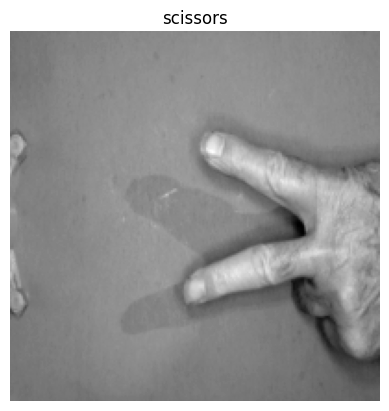

In [9]:
for images, labels in test_ds.take(1):
    
    image = images[0].numpy()
    label = labels[0].numpy()
    prediction = model_1.predict(image[None, ...])

    print(f"Predicted label: {class_names[prediction.argmax()]}")
    print(f"Actual label: {class_names[label]}")

    plt.imshow(image.squeeze(), cmap="gray")
    plt.title(class_names[label])
    plt.axis("off")
    plt.show()

In [10]:
model_2 = keras.Sequential(
    [
        data_augmentation,
    layers.Rescaling(1./255),
   layers.Conv2D(16, (3, 3), activation="relu", input_shape=(128, 128, 1)),
   layers.MaxPooling2D((2, 2)),
   layers.Conv2D(32, (3, 3), activation="relu"),
   layers.MaxPooling2D((2, 2)),
   layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(84, activation="relu"),

    layers.Dense(3,activation='softmax')

    ]
)

In [11]:
model_2.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [12]:
model_2.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [13]:
model_2.fit(train_ds, validation_data=val_ds, epochs=10)

Epoch 1/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 104ms/step - accuracy: 0.3708 - loss: 1.0902 - val_accuracy: 0.6562 - val_loss: 0.8680
Epoch 2/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - accuracy: 0.6606 - loss: 0.8045 - val_accuracy: 0.8719 - val_loss: 0.5180
Epoch 3/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - accuracy: 0.7730 - loss: 0.5589 - val_accuracy: 0.9375 - val_loss: 0.3255
Epoch 4/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 95ms/step - accuracy: 0.8604 - loss: 0.3852 - val_accuracy: 0.9406 - val_loss: 0.2207
Epoch 5/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 95ms/step - accuracy: 0.9125 - loss: 0.2596 - val_accuracy: 0.9375 - val_loss: 0.2077
Epoch 6/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - accuracy: 0.9402 - loss: 0.1887 - val_accuracy: 0.9563 - val_loss: 0.1304
Epoch 7/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - accuracy: 0.9424 - loss: 0.1739 - val_accuracy: 0.9406 - val_loss: 0.2308
Epoch 8/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - accuracy: 0.9491 - loss: 0.1525 - val_accuracy: 0.9906 - 

In [30]:
model_3 = keras.Sequential([
    data_augmentation,
    layers.Rescaling(1./255),
    
    layers.Conv2D(16, (5, 5), activation="relu", input_shape=(200, 200, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(32, (5, 5), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    
    layers.Flatten(),
    layers.Dense(128, activation="relu",name='dense_1'),
    layers.Dropout(0.2),
    layers.Dense(64,activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(3, activation='softmax')
])

In [31]:
model_3.summary()


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 200, 200, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_6 (Rescaling)         │ (None, 200, 200, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 196, 196, 16)   │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 98, 98, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 94, 94, 32)     │        12,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 47, 47, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 20, 20, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │     1,638,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,752,579 (6.69 MB)

 Trainable params: 1,752,579 (6.69 MB)

 Non-trainable params: 0 (0.00 B)

In [32]:
model_3.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
model_3.fit(train_ds, validation_data=val_ds, epochs=10)

Epoch 1/10


48/48 ━━━━━━━━━━━━━━━━━━━━ 9s 142ms/step - accuracy: 0.3523 - loss: 1.1003 - val_accuracy: 0.3219 - val_loss: 1.0197
Epoch 2/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 6s 131ms/step - accuracy: 0.5651 - loss: 0.9169 - val_accuracy: 0.7563 - val_loss: 0.5982
Epoch 3/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 6s 129ms/step - accuracy: 0.7438 - loss: 0.6400 - val_accuracy: 0.8531 - val_loss: 0.4238
Epoch 4/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 6s 130ms/step - accuracy: 0.8372 - loss: 0.4744 - val_accuracy: 0.8562 - val_loss: 0.3991
Epoch 5/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 6s 128ms/step - accuracy: 0.8765 - loss: 0.3706 - val_accuracy: 0.9688 - val_loss: 0.1170
Epoch 6/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 6s 130ms/step - accuracy: 0.9341 - loss: 0.2121 - val_accuracy: 0.9719 - val_loss: 0.1034
Epoch 7/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 6s 129ms/step - accuracy: 0.9207 - loss: 0.2567 - val_accuracy: 0.9625 - val_loss: 0.1256
Epoch 8/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 7s 135ms/step - accuracy: 0.9436 - loss: 0.1840 - val_accuracy: 0.9750 - val_

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step
Predicted label: scissors
Actual label: scissors


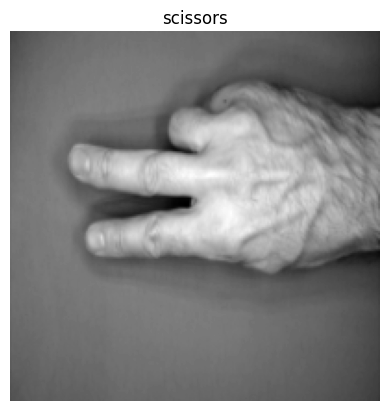

In [26]:
for images, labels in test_ds.take(1):
    
    image = images[0].numpy()
    label = labels[0].numpy()
    prediction = model_3.predict(image[None, ...])

    print(f"Predicted label: {class_names[prediction.argmax()]}")
    print(f"Actual label: {class_names[label]}")

    plt.imshow(image.squeeze(), cmap="gray")
    plt.title(class_names[label])
    plt.axis("off")
    plt.show()

<h3>Dead neurons problem</h3>

<p>80% of the neurons are dead </p>

In [18]:
from tensorflow.keras.models import Model
import numpy as np

# Create a model that outputs activations of a specific layer
layer_output_model = Model(inputs=model_3.inputs,
                           outputs=model_3.get_layer("dense_1").output)

activations = layer_output_model.predict(image[None, ...])

# Count zeros
zero_fraction = np.mean(activations == 0)
print("Fraction of zero activations:", zero_fraction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
Fraction of zero activations: 0.859375


In [19]:
model_3 = keras.Sequential([
    data_augmentation,
    layers.Rescaling(1./255),
    
    layers.Conv2D(16, (7, 7), input_shape=(128, 128, 1)),
    layers.LeakyReLU(alpha=0.01),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(32, (5, 5)),
    layers.LeakyReLU(alpha=0.01),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(64, (3, 3)),
    layers.LeakyReLU(alpha=0.01),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3)),
    layers.LeakyReLU(alpha=0.01),
    layers.MaxPooling2D((2, 2)),
    
    
    layers.Flatten(),
    layers.Dense(128),
    layers.LeakyReLU(alpha=0.01),
    layers.Dropout(0.2),
    layers.Dense(64),
    layers.LeakyReLU(alpha=0.01),
    layers.Dropout(0.2),
    layers.Dense(3, activation='softmax')
])

c:\Users\loren\anaconda3\envs\MLstat\lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


In [20]:
model_3.summary()
model_3.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 200, 200, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_3 (Rescaling)         │ (None, 200, 200, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 194, 194, 16)   │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 194, 194, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 97, 97, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 93, 93, 32)     │        12,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 93, 93, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 46, 46, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 44, 44, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 44, 44, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 20, 20, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │     1,638,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,752,963 (6.69 MB)

 Trainable params: 1,752,963 (6.69 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
model_3.fit(train_ds, validation_data=val_ds, epochs=10)

Epoch 1/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 10s 152ms/step - accuracy: 0.3371 - loss: 1.1007 - val_accuracy: 0.2750 - val_loss: 1.1015
Epoch 2/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 6s 133ms/step - accuracy: 0.3353 - loss: 1.0991 - val_accuracy: 0.2969 - val_loss: 1.0679
Epoch 3/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 7s 134ms/step - accuracy: 0.5322 - loss: 0.9808 - val_accuracy: 0.7656 - val_loss: 0.5603
Epoch 4/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 6s 134ms/step - accuracy: 0.7255 - loss: 0.7117 - val_accuracy: 0.8625 - val_loss: 0.4349
Epoch 5/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 6s 134ms/step - accuracy: 0.8060 - loss: 0.5092 - val_accuracy: 0.8875 - val_loss: 0.3103
Epoch 6/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 7s 136ms/step - accuracy: 0.8773 - loss: 0.3684 - val_accuracy: 0.9250 - val_loss: 0.2510
Epoch 7/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 6s 133ms/step - accuracy: 0.8846 - loss: 0.3657 - val_accuracy: 0.9094 - val_loss: 0.2171
Epoch 8/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 7s 135ms/step - accuracy: 0.9076 - loss: 0.2897 - val_accuracy: 0

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
Predicted label: rock
Actual label: rock


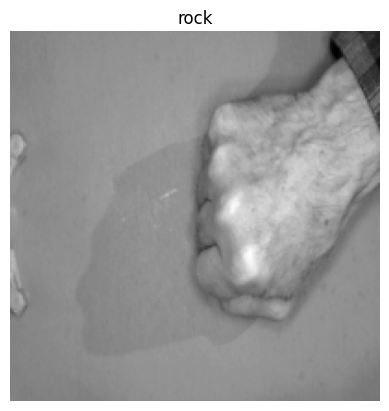

In [22]:
for images, labels in test_ds.take(1):
    
    image = images[0].numpy()
    label = labels[0].numpy()
    prediction = model_3.predict(image[None, ...])

    print(f"Predicted label: {class_names[prediction.argmax()]}")
    print(f"Actual label: {class_names[label]}")

    plt.imshow(image.squeeze(), cmap="gray")
    plt.title(class_names[label])
    plt.axis("off")
    plt.show()